In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

import joblib

from pytorch_tabnet.tab_model import TabNetRegressor

# Load Files

In [4]:
df = pd.read_csv("data/CombinedData/cleaned_data_with_physical_model.csv")
df.dropna(inplace=True)

# Plots

In [5]:
def plot_residuals(y_true, y_pred, title='Residual Plot', xlabel='Predicted Values', ylabel='Residuals'):
    # Calculate residuals
    residuals = y_true - y_pred

    # Plot residuals
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [11]:
def plot_actual_vs_predicted(y_true, y_pred, title='Actual vs. Predicted', xlabel='Actual Values', ylabel='Predicted Values'):
    # Scatter plot: Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, color='blue', alpha=0.6, label='Predictions')

    # Perfect fit line (y = x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit (y = x)')

    # Trend Line (Linear Regression)
    model = LinearRegression()
    y_true_reshaped = np.array(y_true).reshape(-1, 1)  # Reshape y_true for fitting
    model.fit(y_true_reshaped, y_pred)
    trend_line = model.predict(y_true_reshaped)

    # Plot the trend line (green dashed line)
    plt.plot(y_true, trend_line, color='green', linestyle='-.', label='Trend Line (Linear Fit)')

    # Add labels, title, and legend
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

In [14]:
def model_metrics(y_true, y_pred):
    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    print(f'Mean Absolute Error: {mae}')

    # Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)
    print(f'Mean Squared Error: {mse}')

    # Root Mean Squared Error
    rmse = mse ** 0.5
    print(f'Root Mean Squared Error: {rmse}')

    # R2 Score
    r2 = r2_score(y_true, y_pred)
    print(f'R2 Score: {r2}')

In [8]:
def heatmap(x, y, **kwargs):
    # https://github.com/drazenz/heatmaps/blob/master/heatmap/heatmap.py
    if 'color' in kwargs:
        color = kwargs['color']
    else:
        color = [1]*len(x)

    if 'palette' in kwargs:
        palette = kwargs['palette']
        n_colors = len(palette)
    else:
        n_colors = 256 # Use 256 colors for the diverging color palette
        palette = sns.color_palette("Blues", n_colors)

    if 'color_range' in kwargs:
        color_min, color_max = kwargs['color_range']
    else:
        color_min, color_max = min(color), max(color) # Range of values that will be mapped to the palette, i.e. min and max possible correlation

    def value_to_color(val):
        if color_min == color_max:
            return palette[-1]
        else:
            val_position = float((val - color_min)) / (color_max - color_min) # position of value in the input range, relative to the length of the input range
            val_position = min(max(val_position, 0), 1) # bound the position betwen 0 and 1
            ind = int(val_position * (n_colors - 1)) # target index in the color palette
            return palette[ind]

    if 'size' in kwargs:
        size = kwargs['size']
    else:
        size = [1]*len(x)

    if 'size_range' in kwargs:
        size_min, size_max = kwargs['size_range'][0], kwargs['size_range'][1]
    else:
        size_min, size_max = min(size), max(size)

    size_scale = kwargs.get('size_scale', 500)

    def value_to_size(val):
        if size_min == size_max:
            return 1 * size_scale
        else:
            val_position = (val - size_min) * 0.99 / (size_max - size_min) + 0.01 # position of value in the input range, relative to the length of the input range
            val_position = min(max(val_position, 0), 1) # bound the position betwen 0 and 1
            return val_position * size_scale
    if 'x_order' in kwargs:
        x_names = [t for t in kwargs['x_order']]
    else:
        x_names = [t for t in sorted(set([v for v in x]))]
    x_to_num = {p[1]:p[0] for p in enumerate(x_names)}

    if 'y_order' in kwargs:
        y_names = [t for t in kwargs['y_order']]
    else:
        y_names = [t for t in sorted(set([v for v in y]))]
    y_to_num = {p[1]:p[0] for p in enumerate(y_names)}

    plot_grid = plt.GridSpec(1, 15, hspace=0.2, wspace=0.1) # Setup a 1x10 grid
    ax = plt.subplot(plot_grid[:,:-1]) # Use the left 14/15ths of the grid for the main plot

    marker = kwargs.get('marker', 's')

    kwargs_pass_on = {k:v for k,v in kwargs.items() if k not in [
         'color', 'palette', 'color_range', 'size', 'size_range', 'size_scale', 'marker', 'x_order', 'y_order', 'xlabel', 'ylabel'
    ]}

    ax.scatter(
        x=[x_to_num[v] for v in x],
        y=[y_to_num[v] for v in y],
        marker=marker,
        s=[value_to_size(v) for v in size],
        c=[value_to_color(v) for v in color],
        **kwargs_pass_on
    )
    ax.set_xticks([v for k,v in x_to_num.items()])
    ax.set_xticklabels([k for k in x_to_num], rotation=90, horizontalalignment='right')
    ax.set_yticks([v for k,v in y_to_num.items()])
    ax.set_yticklabels([k for k in y_to_num])

    ax.grid(False, 'major')
    ax.grid(True, 'minor')
    ax.set_xticks([t + 0.5 for t in ax.get_xticks()], minor=True)
    ax.set_yticks([t + 0.5 for t in ax.get_yticks()], minor=True)

    ax.set_xlim([-0.5, max([v for v in x_to_num.values()]) + 0.5])
    ax.set_ylim([-0.5, max([v for v in y_to_num.values()]) + 0.5])
    ax.set_facecolor('#F1F1F1')

    ax.set_xlabel(kwargs.get('xlabel', ''))
    ax.set_ylabel(kwargs.get('ylabel', ''))

    # Add color legend on the right side of the plot
    if color_min < color_max:
        ax = plt.subplot(plot_grid[:,-1]) # Use the rightmost column of the plot

        col_x = [0]*len(palette) # Fixed x coordinate for the bars
        bar_y=np.linspace(color_min, color_max, n_colors) # y coordinates for each of the n_colors bars

        bar_height = bar_y[1] - bar_y[0]
        ax.barh(
            y=bar_y,
            width=[5]*len(palette), # Make bars 5 units wide
            left=col_x, # Make bars start at 0
            height=bar_height,
            color=palette,
            linewidth=0
        )
        ax.set_xlim(1, 2) # Bars are going from 0 to 5, so lets crop the plot somewhere in the middle
        ax.grid(False) # Hide grid
        ax.set_facecolor('white') # Make background white
        ax.set_xticks([]) # Remove horizontal ticks
        ax.set_yticks(np.linspace(min(bar_y), max(bar_y), 3)) # Show vertical ticks for min, middle and max
        ax.yaxis.tick_right() # Show vertical ticks on the right

def corrplot(data, size_scale=500, marker='s'):
    plt.figure(figsize=(11, 9))  # Set the figure size
    corr = pd.melt(data.reset_index(), id_vars='index').replace(np.nan, 0)
    corr.columns = ['x', 'y', 'value']
    heatmap(
        corr['x'], corr['y'],
        color=corr['value'], color_range=[-1, 1],
        palette=sns.diverging_palette(20, 220, n=256),
        size=corr['value'].abs(), size_range=[0,1],
        marker=marker,
        x_order=data.columns,
        y_order=data.columns[::-1],
        size_scale=size_scale
    )

# Preprocess Data

In [5]:
def preprocess_features(df, log_features, unchanged_features, scale_features, scaler=None):
    """
    Preprocess the dataset by applying log transformation, standard scaling,
    and keeping specified features unchanged.

    Parameters:
        df (pd.DataFrame): The input dataset.
        log_features (list): Features to apply log transformation to.
        unchanged_features (list): Features to keep unchanged.
        scale_features (list): Features to apply standard scaling to.

    Returns:
        pd.DataFrame: Preprocessed dataset.
    """
    # Initialize a scaler for standard scaling
    if scaler is None:
        scaler = StandardScaler()

    # Apply log transformation to specified features
    df_log_transformed = df.copy()
    for feature in log_features:
        if (df[feature] < 0).any():
            raise ValueError(f"Feature '{feature}' has negative values, cannot apply log transformation.")

        # Replace zero with a small positive constant
        df_log_transformed[feature] = df[feature].apply(lambda x: x if x > 0 else 1e-6)
        df_log_transformed[feature] = np.log1p(df_log_transformed[feature])  # Apply log1p transformation

    # Standard scale specified features
    df_scaled = df_log_transformed.copy()
    df_scaled[scale_features] = scaler.fit_transform(df_scaled[scale_features])

    # Drop unchanged features from the processed DataFrame to avoid duplication
    df_scaled = df_scaled.drop(columns=unchanged_features, errors='ignore')

    # Preserve only specified columns for unchanged features
    unchanged_data = df[unchanged_features]

    # Combine all features
    processed_df = pd.concat([df_scaled, unchanged_data], axis=1)

    # Remove duplicate columns if they exist (as a safeguard)
    processed_df = processed_df.loc[:, ~processed_df.columns.duplicated()]

    return processed_df, scaler

In [ ]:
def smart_correlated_selection(X, y):
    # Smart Correlated Selection
    tr = SmartCorrelatedSelection(
        variables=None,
        method="pearson",
        threshold=0.9,
        missing_values="raise",
        selection_method="model_performance",
        estimator=XGBRegressor(random_state=1, n_jobs=-1),
        scoring='neg_mean_squared_error',
        cv=2,
    )

    Xt = tr.fit_transform(X, y)
    features_to_drop = tr.features_to_drop_
    selected_features = Xt.columns
    
    print(f"Correlated features sets: {tr.correlated_feature_sets_}")
    print(f"Correlated features dict: {tr.correlated_feature_dict_}")
    print(f"Features to drop: {features_to_drop}")
    print(f"Selected features: {selected_features}")

    return Xt, features_to_drop, selected_features

# Reduce Multicollinearity

In [61]:
X = df.drop(columns=['produced energy', "relative_output"])
y = df['relative_output']
Xt, features_to_drop, selected_features = smart_correlated_selection(X, y)

Correlated features sets: [{'cell_temp', 'temperature_2m'}, {'month_cos', 'day_of_year_cos'}, {'month_sin', 'day_of_year_sin'}, {'solar_elevation', 'solar_zenith', 'diffuse_radiation'}, {'poa', 'poa_hour_minus_1', 'relative_physical_model_prediction', 'shortwave_radiation', 'direct_radiation', 'direct_normal_irradiance'}, {'hour_cos', 'is_day'}, {'surface_pressure', 'pressure_msl'}]
Correlated features dict: {'cell_temp': {'temperature_2m'}, 'month_cos': {'day_of_year_cos'}, 'day_of_year_sin': {'month_sin'}, 'solar_zenith': {'solar_elevation', 'diffuse_radiation'}, 'poa': {'poa_hour_minus_1', 'relative_physical_model_prediction', 'shortwave_radiation', 'direct_radiation', 'direct_normal_irradiance'}, 'hour_cos': {'is_day'}, 'pressure_msl': {'surface_pressure'}}
Features to drop: ['temperature_2m', 'day_of_year_cos', 'month_sin', 'diffuse_radiation', 'solar_elevation', 'direct_normal_irradiance', 'direct_radiation', 'poa_hour_minus_1', 'relative_physical_model_prediction', 'shortwave_ra

In [263]:
selected_features

['kwp',
 'relative_humidity_2m',
 'dew_point_2m',
 'pressure_msl',
 'precipitation',
 'cloud_cover',
 'wind_speed_10m',
 'wind_direction_10m',
 'solar_zenith',
 'solar_azimuth',
 'poa',
 'clearsky_index',
 'hour_sin',
 'hour_cos',
 'day_of_year_cos',
 'month_cos',
 'cell_temp',
 'relative_physical_model_prediction']

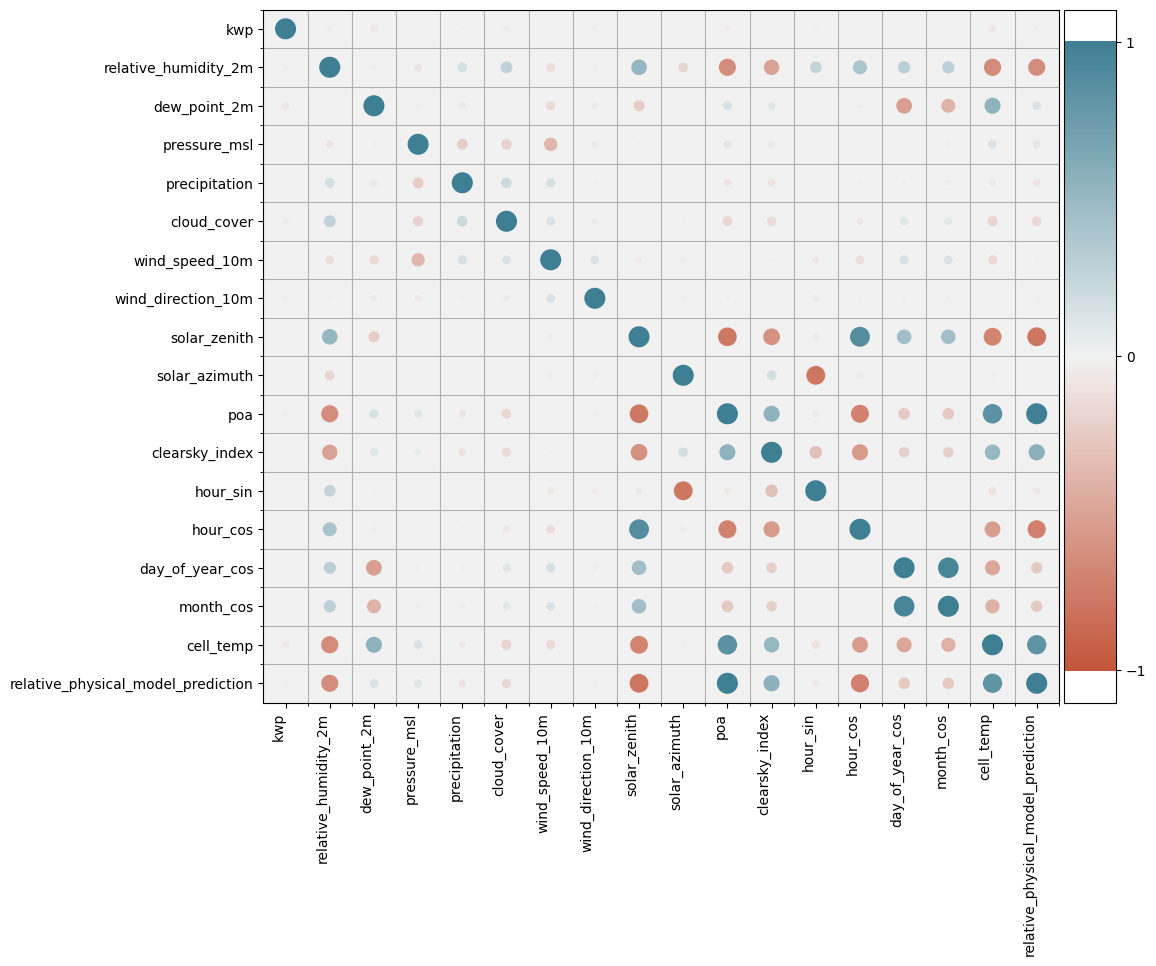

In [264]:
corr = df[selected_features].corr()
corrplot(corr, size_scale=200, marker='o')

# Preprocess Data

In [274]:
df.columns

Index(['produced energy', 'kwp', 'temperature_2m', 'relative_humidity_2m',
       'dew_point_2m', 'pressure_msl', 'surface_pressure', 'precipitation',
       'cloud_cover', 'wind_speed_10m', 'wind_direction_10m',
       'shortwave_radiation', 'diffuse_radiation', 'direct_radiation',
       'direct_normal_irradiance', 'is_day', 'day_of_year', 'solar_zenith',
       'solar_azimuth', 'solar_elevation', 'poa', 'clearsky_index', 'hour_sin',
       'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'month_sin',
       'month_cos', 'cell_temp', 'physical_model_prediction',
       'relative_physical_model_prediction', 'relative_output'],
      dtype='object')

In [59]:
log_features = [
    "kwp",
    "precipitation",
    "shortwave_radiation",
    "diffuse_radiation",
    "direct_radiation",
    "direct_normal_irradiance",
    "poa",
    "physical_model_prediction"
]

unchanged_features = [
    "is_day",
    "hour_sin", "hour_cos",
    "day_of_year", "day_of_year_sin", "day_of_year_cos",
    "month_sin", "month_cos",
    "clearsky_index",
    "relative_physical_model_prediction",
    "relative_output"
]


scale_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "pressure_msl",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "solar_zenith",
    "solar_azimuth",
    "solar_elevation",
    "cell_temp"
]


df, scaler = preprocess_features(df, log_features, unchanged_features, scale_features)

In [1]:
joblib.dump(scaler, "models/scaler.pkl")

NameError: name 'joblib' is not defined

# ML Models


## XGBoost

### Split Data

In [79]:
X = df[selected_features]
y = df['relative_output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Hyperparameter Tuning

### Train Model

In [80]:
xgb_model = XGBRegressor(objective="reg:squarederror", random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
model_metrics(y_test, y_pred_xgb)

Mean Absolute Error: 0.03277726641321989
Mean Squared Error: 0.004326385900688451
Root Mean Squared Error: 0.06577526815367955
R2 Score: 0.8930033283149934


In [81]:
xgb_model.save_model("models/xgboost_model.json")

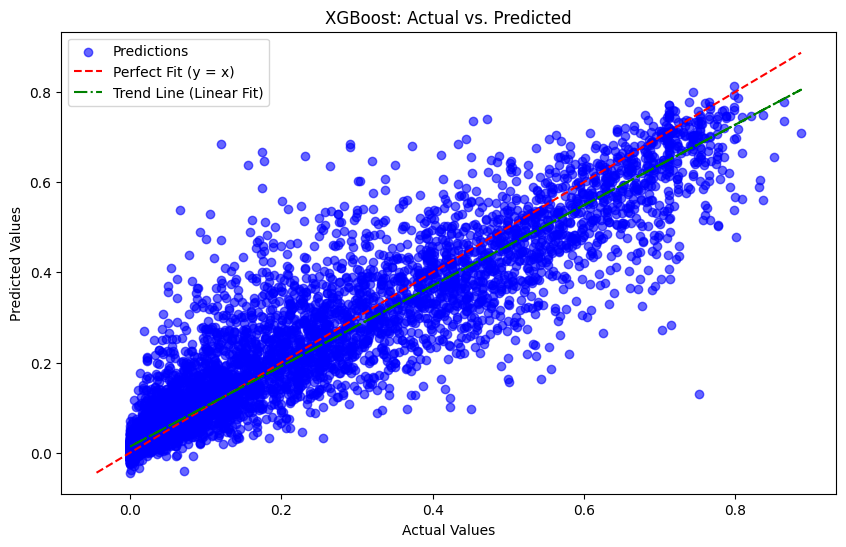

In [278]:
plot_actual_vs_predicted(y_test[:10000], y_pred_xgb[:10000], title='XGBoost: Actual vs. Predicted', xlabel='Actual Values', ylabel='Predicted Values')

Feature Importances:
Feature: poa, Importance: 0.8214
Feature: solar_zenith, Importance: 0.0317
Feature: hour_cos, Importance: 0.0225
Feature: solar_azimuth, Importance: 0.0199
Feature: hour_sin, Importance: 0.0183
Feature: clearsky_index, Importance: 0.0145
Feature: kwp, Importance: 0.0114
Feature: cloud_cover, Importance: 0.0110
Feature: precipitation, Importance: 0.0090
Feature: relative_physical_model_prediction, Importance: 0.0087
Feature: cell_temp, Importance: 0.0078
Feature: month_cos, Importance: 0.0047
Feature: wind_direction_10m, Importance: 0.0040
Feature: dew_point_2m, Importance: 0.0034
Feature: day_of_year_sin, Importance: 0.0034
Feature: pressure_msl, Importance: 0.0033
Feature: relative_humidity_2m, Importance: 0.0032
Feature: wind_speed_10m, Importance: 0.0018


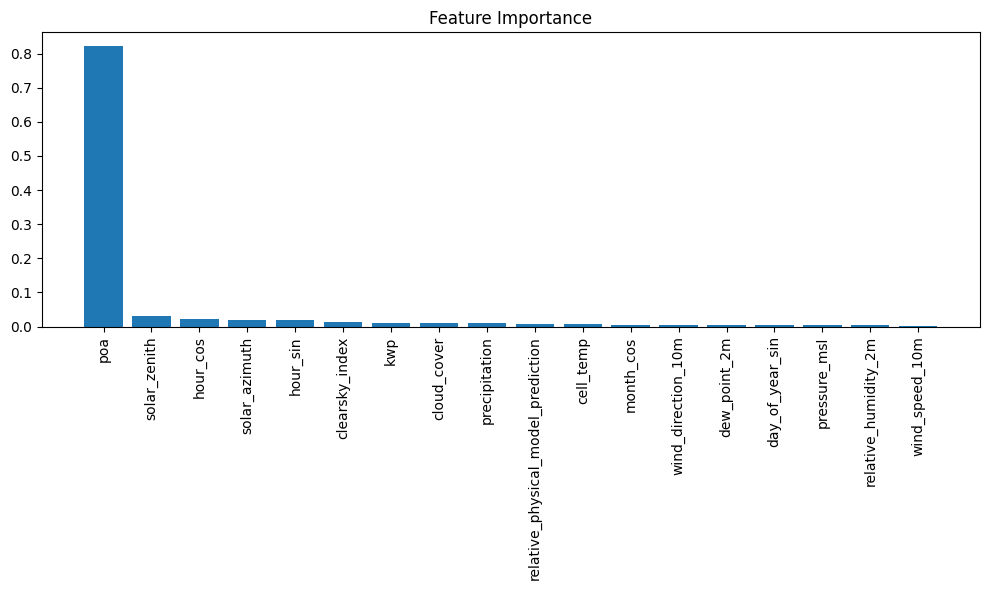

In [279]:
# Feature Importance
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

# Print feature importances
print("Feature Importances:")
for idx in indices:
    print(f"Feature: {features[idx]}, Importance: {importances[idx]:.4f}")

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), np.array(features)[indices], rotation=90)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


In [282]:
# Define the XGBoost model
xgb_model = XGBRegressor(objective="reg:squarederror",  random_state=42)

# Define parameter distributions for Randomized Search
param_distributions = {
    'n_estimators': np.arange(100, 2000, 50),         # Increase trees to learn more
    'max_depth': np.arange(6, 15, 1),               # Allow deeper trees to capture complex patterns
    'learning_rate': np.linspace(0.01, 0.2, 10),    # Test smaller learning rates for finer updates
    'subsample': np.linspace(0.7, 1.0, 5),          # Slightly lower subsampling to avoid overfitting
    'colsample_bytree': np.linspace(0.7, 1.0, 5),   # Reduce columns per tree
    'gamma': np.linspace(0, 1, 5),                  # Allow splits with smaller gains
    'min_child_weight': np.arange(1, 10, 1),        # Test smaller values to better fit high kWp
    'reg_alpha': np.linspace(0, 1, 5),              # L1 regularization (smaller values to reduce restrictions)
    'reg_lambda': np.linspace(0.5, 2, 5),           # L2 regularization (for generalization)
}

# RandomizedSearchCV configuration
random_search_xg = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=500,  # Number of parameter settings sampled
    scoring='neg_mean_squared_error',  # Use MSE as scoring metric
    cv=2,  # 3-fold cross-validation
    verbose=2,  # Show progress
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# Run the random search
random_search_xg.fit(X_train, y_train)


# Evaluate the best model on the test set
best_model_xg = random_search_xg.best_estimator_
y_pred_xg = best_model_xg.predict(X_test)

Fitting 2 folds for each of 500 candidates, totalling 1000 fits
[CV] END colsample_bytree=0.85, gamma=1.0, learning_rate=0.1577777777777778, max_depth=13, min_child_weight=6, n_estimators=500, reg_alpha=0.25, reg_lambda=0.875, subsample=0.85; total time=   7.6s
[CV] END colsample_bytree=0.7, gamma=0.75, learning_rate=0.09444444444444444, max_depth=11, min_child_weight=5, n_estimators=400, reg_alpha=0.75, reg_lambda=1.625, subsample=0.85; total time=   8.2s
[CV] END colsample_bytree=0.7, gamma=0.75, learning_rate=0.09444444444444444, max_depth=11, min_child_weight=5, n_estimators=400, reg_alpha=0.75, reg_lambda=1.625, subsample=0.85; total time=   8.8s
[CV] END colsample_bytree=0.85, gamma=1.0, learning_rate=0.1577777777777778, max_depth=13, min_child_weight=6, n_estimators=500, reg_alpha=0.25, reg_lambda=0.875, subsample=0.85; total time=   8.8s
[CV] END colsample_bytree=0.85, gamma=1.0, learning_rate=0.1577777777777778, max_depth=10, min_child_weight=6, n_estimators=900, reg_alpha=0.2

In [1]:
# Best parameters and score
print("Best parameters:", random_search_xg.best_params_)
print("Best CV score (MSE):", -random_search_xg.best_score_)

NameError: name 'random_search_xg' is not defined

### Model Metrics

In [ ]:
model_metrics(y_test, y_pred_xg)

Mean Absolute Error: 0.027014566548241654
Mean Squared Error: 0.003377432267698418
Root Mean Squared Error: 0.05811568005021036
R2 Score: 0.9164720809052724


### Plot Results

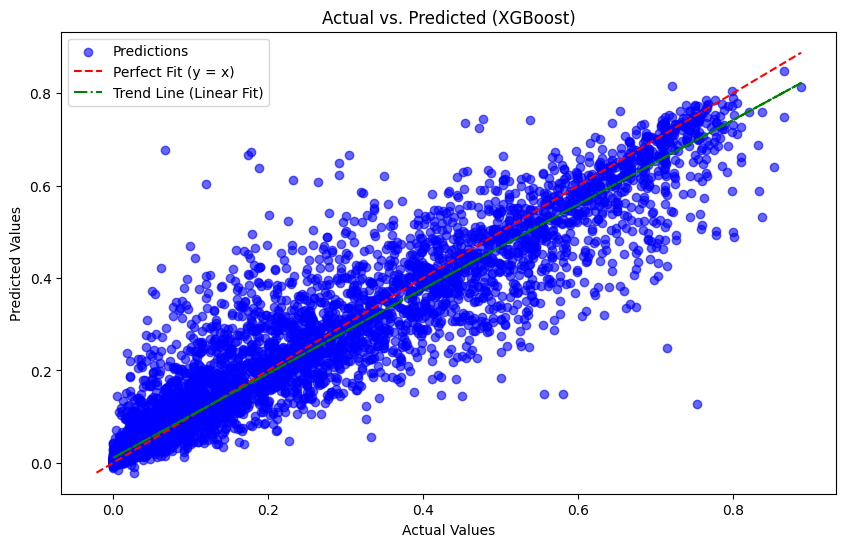

In [285]:
# Plot Actual vs Predicted
plot_actual_vs_predicted(y_test[:10000], y_pred_xg[:10000], title='Actual vs. Predicted (XGBoost)', xlabel='Actual Values', ylabel='Predicted Values')

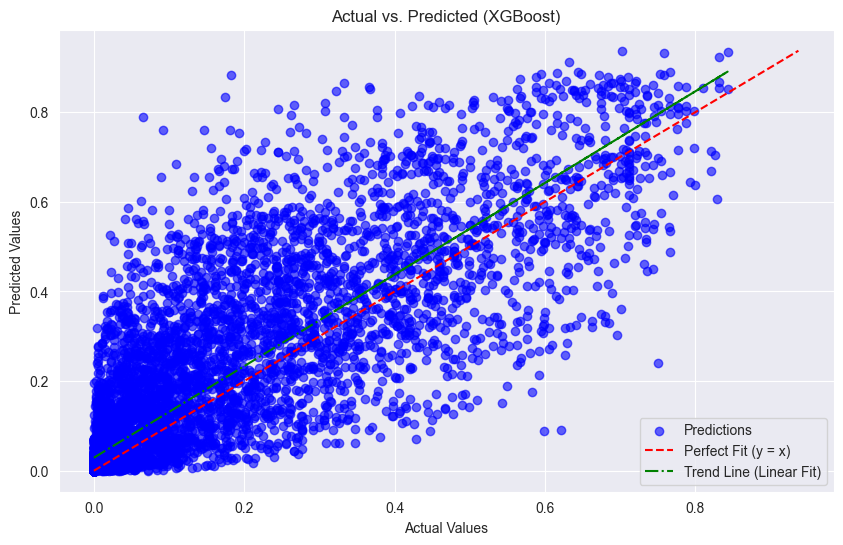

In [191]:
# Plot Actual vs Predicted
plot_actual_vs_predicted(y_test[:10000], X_test["relative_physical_model_prediction"][:10000], title='Actual vs. Predicted (XGBoost)', xlabel='Actual Values', ylabel='Predicted Values')

Feature Importances:
Feature: poa, Importance: 0.5244
Feature: relative_physical_model_prediction, Importance: 0.2001
Feature: solar_zenith, Importance: 0.0698
Feature: hour_sin, Importance: 0.0406
Feature: hour_cos, Importance: 0.0278
Feature: kwp, Importance: 0.0270
Feature: clearsky_index, Importance: 0.0217
Feature: solar_azimuth, Importance: 0.0180
Feature: month_cos, Importance: 0.0121
Feature: cell_temp, Importance: 0.0102
Feature: cloud_cover, Importance: 0.0087
Feature: precipitation, Importance: 0.0082
Feature: day_of_year_sin, Importance: 0.0070
Feature: wind_direction_10m, Importance: 0.0057
Feature: relative_humidity_2m, Importance: 0.0055
Feature: pressure_msl, Importance: 0.0049
Feature: dew_point_2m, Importance: 0.0045
Feature: wind_speed_10m, Importance: 0.0038


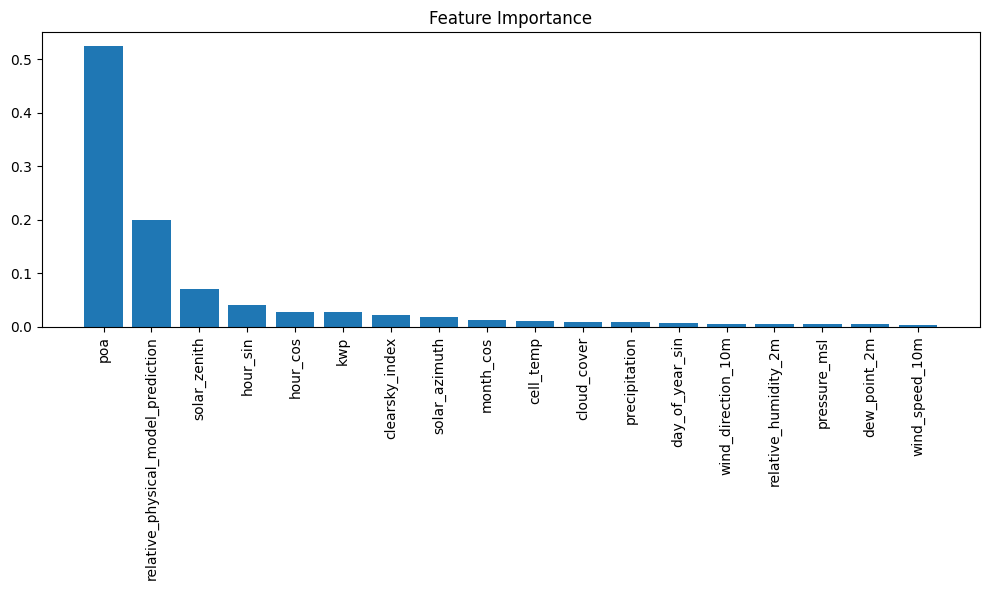

In [286]:
# Feature Importance
importances = best_model_xg.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

# Print feature importances
print("Feature Importances:")
for idx in indices:
    print(f"Feature: {features[idx]}, Importance: {importances[idx]:.4f}")

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), np.array(features)[indices], rotation=90)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


### Save Model

In [ ]:
# save xgboost
best_model_xg.save_model("models/xgboost_model_1000_iter_hypertune.json")

['models/xgboost_model_1000_iter_hypertune.pkl']

## Random Forest

### Split Data

In [288]:
X = df[selected_features]
y = df['relative_output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Model

In [289]:
# Define and train the Random Forest model
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

### Model Metrics

In [290]:
# Model Metrics
model_metrics(y_test, y_pred_rf)

Mean Absolute Error: 0.03635125813577413
Mean Squared Error: 0.005462463094114342
Root Mean Squared Error: 0.07390847782300987
R2 Score: 0.8649067873997527


### Plot Results

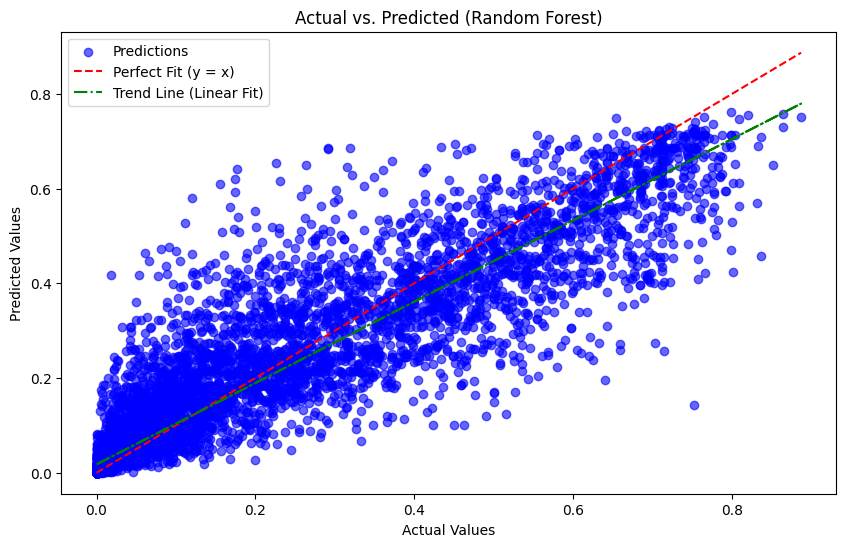

In [291]:
plot_actual_vs_predicted(y_test[:10000], y_pred_rf[:10000], title='Actual vs. Predicted (Random Forest)', xlabel='Actual Values', ylabel='Predicted Values')

### Save Model

In [292]:
joblib.dump(rf, "models/random_forest_model.pkl")

['models/random_forest_model.pkl']

## RF Hypertune

### Split Data

In [ ]:
X = df[selected_features]
y = df['relative_output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [293]:
# Define the hyperparameter grid
rf_param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],  # Number of trees
    'max_depth': [None, 10, 20, 30, 40, 50],   # Maximum depth of trees
    'min_samples_split': [2, 5, 10],           # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],             # Minimum samples required at a leaf node
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider for best split
    'bootstrap': [True, False]                 # Whether bootstrap samples are used
}

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)  # Use all available cores

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_distributions,
    n_iter=100,  # Number of parameter settings sampled
    scoring='neg_mean_squared_error',  # Use MSE as scoring metric
    cv=2,  # 3-fold cross-validation
    verbose=2,  # Show progress
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# Perform the hyperparameter search
random_search_rf.fit(X_train, y_train)

# Output the best parameters and score
print("Best Parameters:", random_search_rf.best_params_)
print("Best Score (Negative MSE):", random_search_rf.best_score_)

# Evaluate the best model
best_rf = random_search_rf.best_estimator_
y_pred_hyper_tune_rf = best_rf.predict(X_test)

# Evaluate the model
model_metrics(y_test, y_pred_hyper_tune_rf)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END bootstrap=True, max_depth=40, max_features=auto, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   1.1s
[CV] END bootstrap=True, max_depth=40, max_features=auto, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   1.0s
[CV] END bootstrap=True, max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END bootstrap=True, max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END bootstrap=False, max_depth=20, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 2.4min
[CV] END bootstrap=False, max_depth=20, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 2.4min


/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=False, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END bootstrap=False, max_depth=50, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 2.7min
[CV] END bootstrap=False, max_depth=50, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 2.7min
[CV] END bootstrap=True, max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.4s
[CV] END bootstrap=False, max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END bootstrap=True, max_depth=40, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time= 1.9min
[CV] END bootstrap=False, max_depth=None

/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
84 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
52 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/sklearn/base.py", 

Best Parameters: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': False}
Best Score (Negative MSE): -0.004446426571469996
Mean Absolute Error: 0.03072162765227374
Mean Squared Error: 0.004227124174775541
Root Mean Squared Error: 0.06501633775271828
R2 Score: 0.8954581889173961


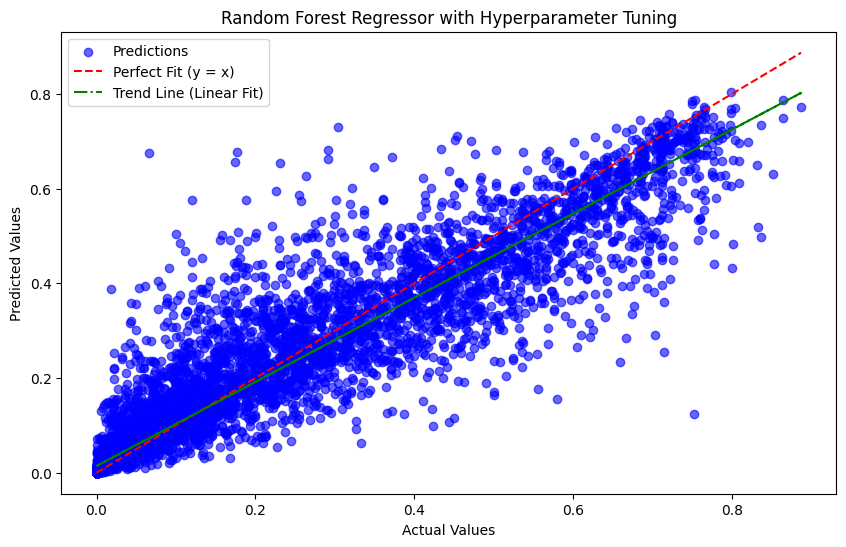

In [295]:
plot_actual_vs_predicted(y_test[:10000], y_pred_hyper_tune_rf[:10000], "Random Forest Regressor with Hyperparameter Tuning")

In [297]:
joblib.dump(best_rf, "models/random_forest_regressor_hyper_tune.pkl")

['models/random_forest_regressor_hyper_tune.pkl']

Feature Importances:
Feature: poa, Importance: 0.2448
Feature: relative_physical_model_prediction, Importance: 0.2163
Feature: solar_zenith, Importance: 0.1320
Feature: cell_temp, Importance: 0.1034
Feature: clearsky_index, Importance: 0.0803
Feature: hour_cos, Importance: 0.0552
Feature: relative_humidity_2m, Importance: 0.0364
Feature: solar_azimuth, Importance: 0.0295
Feature: kwp, Importance: 0.0208
Feature: cloud_cover, Importance: 0.0142
Feature: hour_sin, Importance: 0.0129
Feature: wind_direction_10m, Importance: 0.0101
Feature: day_of_year_sin, Importance: 0.0100
Feature: pressure_msl, Importance: 0.0084
Feature: dew_point_2m, Importance: 0.0083
Feature: month_cos, Importance: 0.0082
Feature: wind_speed_10m, Importance: 0.0066
Feature: precipitation, Importance: 0.0026


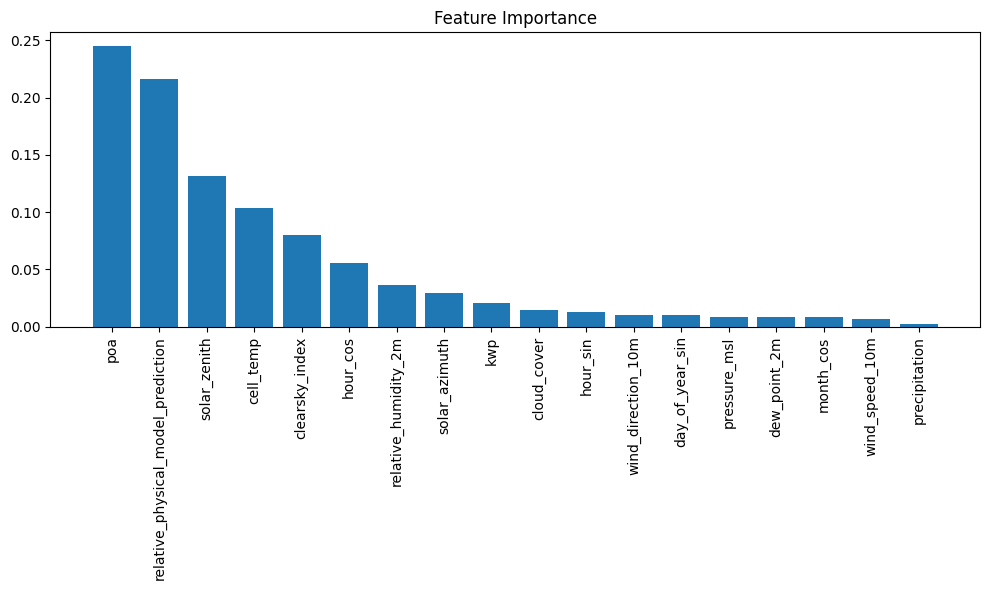

In [303]:
# Feature Importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

# Print feature importances
print("Feature Importances:")
for idx in indices:
    print(f"Feature: {features[idx]}, Importance: {importances[idx]:.4f}")

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), np.array(features)[indices], rotation=90)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## Tabnet

### Split Data

In [310]:
tabnet_df = df.copy()
tabnet_df = tabnet_df.sample(n=200000, random_state=42) # TabNet requires high computational resources

X = tabnet_df[selected_features]
y = tabnet_df['relative_output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Model

In [ ]:
X_train = X_train.values  # Convert to NumPy array
X_test = X_test.values  # Convert to NumPy array

y_train = y_train.values.reshape(-1, 1)  # Reshape to 2D for TabNet
y_test = y_test.values.reshape(-1, 1)  # Reshape to 2D for TabNet

# Define and train TabNet model
tabnet = TabNetRegressor(verbose=10)
tabnet.fit(
    X_train, y_train,  # Pass reshaped targets
    eval_set=[(X_test, y_test)],  # Pass reshaped test targets
    eval_metric=['rmse'],
    max_epochs=100,
    patience=10,
    batch_size=256
)

# Make predictions
y_pred_tabnet = tabnet.predict(X_test)
y_pred_tabnet = np.maximum(y_pred_tabnet, 0)  # Ensure predictions are non-negative

/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


### Model Metric

In [13]:
# Model Metrics
model_metrics(y_test, y_pred_tabnet)

Mean Absolute Error: 0.033149738806121834
Mean Squared Error: 0.004545885019085949
Root Mean Squared Error: 0.06742317864863648
R2 Score: 0.8531408734496332


### Plot Results

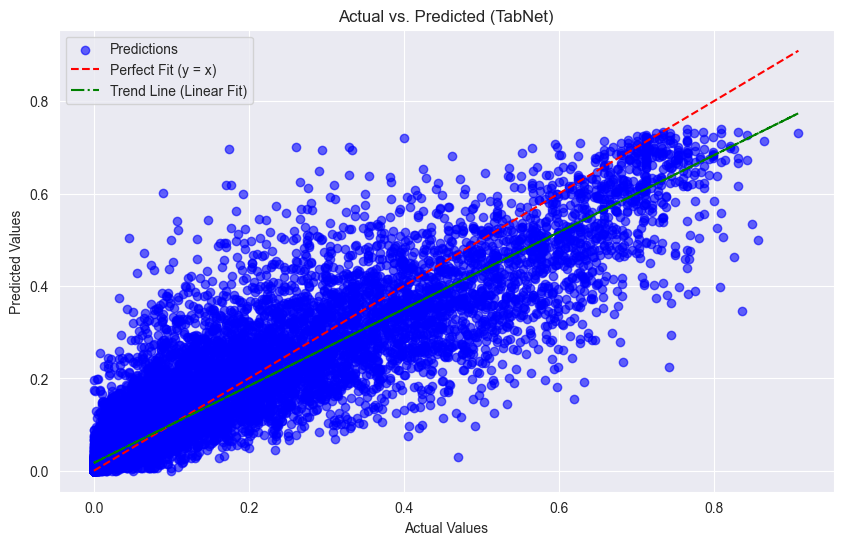

In [14]:
plot_actual_vs_predicted(y_test, y_pred_tabnet, title='Actual vs. Predicted (TabNet)', xlabel='Actual Values', ylabel='Predicted Values')

### Feature importance

In [301]:
print("Feature Importance:", tabnet.feature_importances_)

NameError: name 'tabnet' is not defined

## MLP

### Split Data


In [21]:
X = df[selected_features]
y = df['relative_output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Model

In [22]:
# Define and train the MLP model
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  # Three hidden layers
    activation='relu',                # Activation function
    solver='adam',                    # Optimizer
    alpha=0.0001,                     # L2 regularization
    batch_size=128,                   # Batch size
    max_iter=100,                     # Maximum iterations
    random_state=42,
    early_stopping=True,              # Enable early stopping
    verbose=True                      # Enable verbose output
)
mlp.fit(X_train, y_train)

# Predictions
y_pred_mlp = mlp.predict(X_test)

Iteration 1, loss = 0.00309059
Validation score: 0.859386
Iteration 2, loss = 0.00265447
Validation score: 0.876866
Iteration 3, loss = 0.00254550
Validation score: 0.876106
Iteration 4, loss = 0.00249497
Validation score: 0.881052
Iteration 5, loss = 0.00246614
Validation score: 0.882886
Iteration 6, loss = 0.00244061
Validation score: 0.878487
Iteration 7, loss = 0.00242668
Validation score: 0.883694
Iteration 8, loss = 0.00240972
Validation score: 0.884382
Iteration 9, loss = 0.00239812
Validation score: 0.884793
Iteration 10, loss = 0.00238918
Validation score: 0.883216
Iteration 11, loss = 0.00238302
Validation score: 0.883927
Iteration 12, loss = 0.00237206
Validation score: 0.885772
Iteration 13, loss = 0.00236984
Validation score: 0.886619
Iteration 14, loss = 0.00236226
Validation score: 0.885833
Iteration 15, loss = 0.00236000
Validation score: 0.886554
Iteration 16, loss = 0.00235821
Validation score: 0.886431
Iteration 17, loss = 0.00234964
Validation score: 0.886723
Iterat

### Model Metrics

In [23]:
y_pred_mlp = np.maximum(y_pred_mlp, 0)  # Ensure predictions are non-negative
model_metrics(y_test, y_pred_mlp)

Mean Absolute Error: 0.03159449758978598
Mean Squared Error: 0.004377593194514072
Root Mean Squared Error: 0.06616338258065463
R2 Score: 0.8917369110024588


### Plot Results

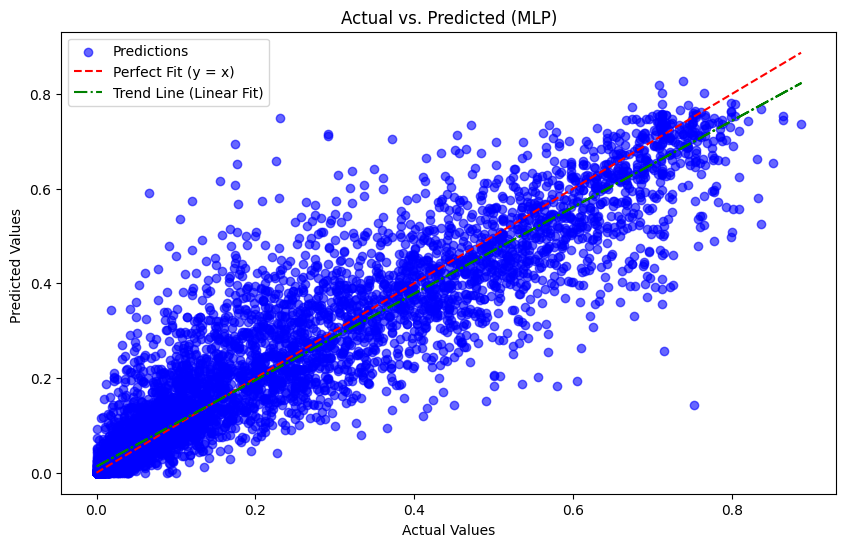

In [24]:
plot_actual_vs_predicted(y_test[:10000], y_pred_mlp[:10000], title='Actual vs. Predicted (MLP)', xlabel='Actual Values', ylabel='Predicted Values ')

### Save Model

In [25]:
joblib.dump(mlp, "models/mlp_model.pkl")

['models/mlp_model.pkl']

## MLP HYPERTUNE

### Split Data

In [26]:
X = df[selected_features]
y = df['relative_output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Define the hyperparameter grid
param_grid = {
    'hidden_layer_sizes': [(128,), (128, 64, 32), (256, 128, 64), (64, 32), (256, 128)],  # Different hidden layer configurations
    'activation': ['relu', 'tanh'],  # Activation functions
    'solver': ['adam', 'sgd'],  # Optimizers
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],  # L2 regularization strength
    'learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],  # Learning rate
    'max_iter': [50, 100, 150],  # Number of iterations
    'batch_size': [32, 64, 128, 256],  # Batch size
    'early_stopping': [True],  # Enable early stopping
    'verbose': [True],  # Enable verbose output
    'learning_rate': ['constant', 'adaptive']  # Learning rate schedule
}

In [30]:
# Initialize the MLPRegressor
mlp = MLPRegressor(
    random_state=42       # Reproducibility
)

# Initialize RandomizedSearchCV
random_search_mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_grid,
    n_iter=25,                    # Number of random samples to try
    scoring='neg_mean_squared_error',  # Use MSE as a regression metric
    cv=2,                         # 5-fold cross-validation
    verbose=2,                    # Enable verbose output
    random_state=42,
    n_jobs=-1                     # Use all available CPU cores
)

In [31]:
# Perform the hyperparameter search
random_search_mlp.fit(X_train, y_train)

# Output the best parameters and score
print("Best Parameters:", random_search_mlp.best_params_)
print("Best Score (Negative MSE):", random_search_mlp.best_score_)

# Evaluate the best model
best_mlp = random_search_mlp.best_estimator_
y_pred_hyper_tune_mlp = best_mlp.predict(X_test)

model_metrics(y_test, y_pred_hyper_tune_mlp)

Fitting 2 folds for each of 25 candidates, totalling 50 fits


Iteration 1, loss = 0.00822091
Validation score: 0.769966
Iteration 1, loss = 0.00819011
Validation score: 0.770117
Iteration 1, loss = 0.00366990
Validation score: 0.835604
Iteration 1, loss = 0.00363774
Validation score: 0.831455
Iteration 2, loss = 0.00572362
Validation score: 0.794492
Iteration 2, loss = 0.00568745
Validation score: 0.794704
Iteration 1, loss = 0.00633174
Iteration 2, loss = 0.00314366
Validation score: 0.822149
Validation score: 0.842735
Iteration 1, loss = 0.00349691
Validation score: 0.862027
Iteration 3, loss = 0.00540005
Iteration 3, loss = 0.00536992
Iteration 1, loss = 0.00349019
Validation score: 0.804488
Validation score: 0.804081
Validation score: 0.863655
Iteration 2, loss = 0.00320319
Validation score: 0.848837
Iteration 1, loss = 0.00617740
Validation score: 0.832384
Iteration 3, loss = 0.00303507
Validation score: 0.853820
Iteration 4, loss = 0.00520259
Validation score: 0.810701
Iteration 4, loss = 0.00522840
Validation score: 0.810392
Iteration 5, l

/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Validation score: 0.882763
Iteration 18, loss = 0.00243664
Validation score: 0.848257
Validation score: 0.882662
Iteration 19, loss = 0.00363583
Validation score: 0.822091
Iteration 13, loss = 0.00374674
[CV] END activation=tanh, alpha=0.01, batch_size=256, early_stopping=True, hidden_layer_sizes=(64, 32), learning_rate=constant, learning_rate_init=0.005, max_iter=50, solver=sgd, verbose=True; total time=  55.1s
Validation score: 0.815943
Iteration 48, loss = 0.00420507
Validation score: 0.846853
Iteration 14, loss = 0.00362244
Validation score: 0.835165
Iteration 20, loss = 0.00361806
Validation score: 0.822695
Iteration 14, loss = 0.00371948
Validation score: 0.817160
Iteration 1, loss = 0.00944437
Validation score: 0.786097
Iteration 49, loss = 0.00419696
Validation score: 0.847031
Iteration 18, loss = 0.00241294
Iteration 19, loss = 0.00243320
Validation score: 0.884135
Validation score: 0.877774
Iteration 14, loss = 0.00353400
Iteration 50, loss = 0.00418940
Iteration 2, loss = 0.

/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Iteration 44, loss = 0.00427119
Validation score: 0.858209
[CV] END activation=tanh, alpha=0.01, batch_size=256, early_stopping=True, hidden_layer_sizes=(256, 128, 64), learning_rate=adaptive, learning_rate_init=0.005, max_iter=100, solver=sgd, verbose=True; total time= 5.1min
Iteration 41, loss = 0.00432844
Validation score: 0.860748
Iteration 45, loss = 0.00426512
Validation score: 0.858259
Iteration 35, loss = 0.00219932
Iteration 42, loss = 0.00432146
Validation score: 0.861055
Validation score: 0.887131
Iteration 46, loss = 0.00425846
Validation score: 0.858469
Iteration 43, loss = 0.00431474
Validation score: 0.860877
Iteration 47, loss = 0.00425280
Validation score: 0.858764
Iteration 36, loss = 0.00220104
Validation score: 0.889564
Iteration 44, loss = 0.00430826
Validation score: 0.861385
Iteration 48, loss = 0.00424627
Validation score: 0.858901
Iteration 49, loss = 0.00424031
Validation score: 0.859058
Iteration 45, loss = 0.00430114
Validation score: 0.861158
Iteration 37, 

/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, alpha=0.001, batch_size=64, early_stopping=True, hidden_layer_sizes=(256, 128), learning_rate=adaptive, learning_rate_init=0.001, max_iter=100, solver=sgd, verbose=True; total time=10.1min
Iteration 92, loss = 0.00405998
Validation score: 0.868052
Iteration 93, loss = 0.00405633
Validation score: 0.868110
Iteration 94, loss = 0.00405116
Validation score: 0.868300
Iteration 95, loss = 0.00404727
Validation score: 0.867818
Iteration 96, loss = 0.00404301
Validation score: 0.868280
Iteration 97, loss = 0.00403888
Validation score: 0.868508
Iteration 98, loss = 0.00403495
Validation score: 0.868619
Iteration 99, loss = 0.00403067
Validation score: 0.868801
Iteration 100, loss = 0.00402610
Validation score: 0.868290


/Users/entl/Library/Mobile Documents/com~apple~CloudDocs/University/Final Project/ML/ml/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, alpha=0.001, batch_size=64, early_stopping=True, hidden_layer_sizes=(256, 128), learning_rate=adaptive, learning_rate_init=0.001, max_iter=100, solver=sgd, verbose=True; total time=10.7min
Iteration 1, loss = 0.00291932
Validation score: 0.868784
Iteration 2, loss = 0.00257588
Validation score: 0.869650
Iteration 3, loss = 0.00249413
Validation score: 0.879639
Iteration 4, loss = 0.00244408
Validation score: 0.877595
Iteration 5, loss = 0.00241304
Validation score: 0.884432
Iteration 6, loss = 0.00239032
Validation score: 0.884203
Iteration 7, loss = 0.00237594
Validation score: 0.884777
Iteration 8, loss = 0.00235920
Validation score: 0.883985
Iteration 9, loss = 0.00234890
Validation score: 0.884313
Iteration 10, loss = 0.00233954
Validation score: 0.886412
Iteration 11, loss = 0.00232890
Validation score: 0.884407
Iteration 12, loss = 0.00232216
Validation score: 0.883511
Iteration 13, loss = 0.00231516
Validation score: 0.886469
Iteration 14, loss = 0.0023

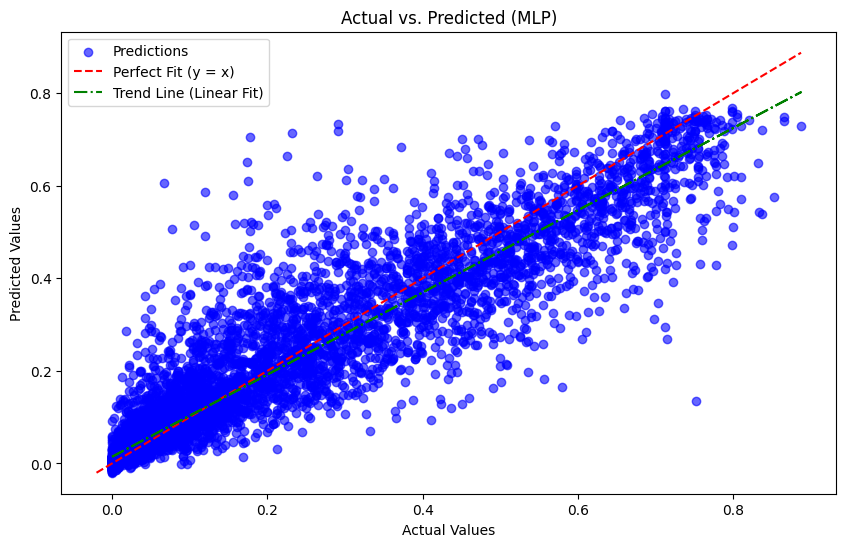

In [32]:
plot_actual_vs_predicted(y_test[:10000], y_pred_hyper_tune_mlp[:10000], title='Actual vs. Predicted (MLP)', xlabel='Actual Values', ylabel='Predicted Values')

In [33]:
joblib.dump(best_mlp, "models/mlp_hyper_tune_model.pkl")


['models/mlp_hyper_tune_model.pkl']

## SVR

### Split Data

In [ ]:
svr_df = df.copy()
svr_df = svr_df.sample(n=10000, random_state=42) # SVR is slow with large datasets

X = df[selected_features]
y = df['produced energy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Model

In [ ]:
from sklearn.svm import SVR, LinearSVR

# Define and train the SVR model
svr = SVR(kernel='linear', C=1.0, epsilon=0.1)

svr.fit(X_train, y_train)

# Predictions
y_pred_svr = svr.predict(X_test)

### Model Metrics

In [ ]:
# Model Metrics
model_metrics(y_test, y_pred_svr)

# TEST

In [72]:
# load
import xgboost as xgb
xgb_model = xgb.XGBRegressor()
xgb_model.load_model("models/xgboost_model_1000_hypertuned.json")


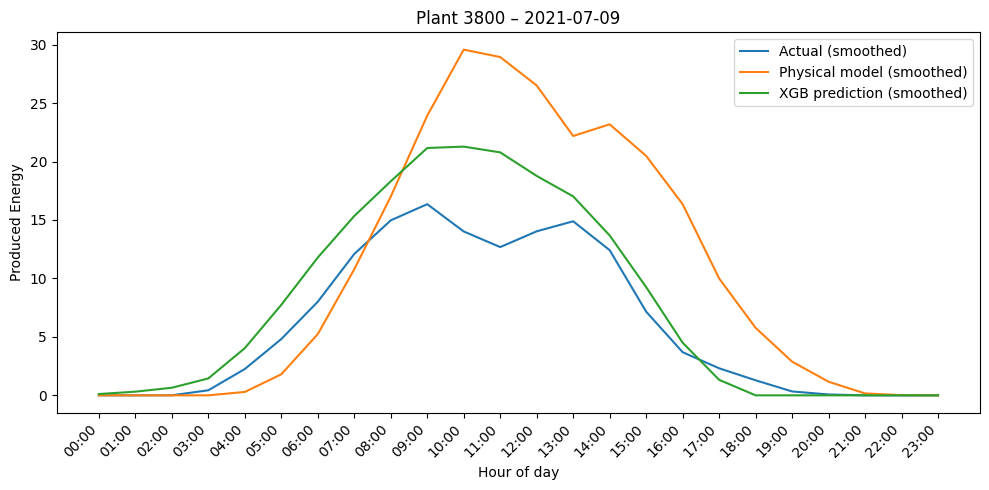

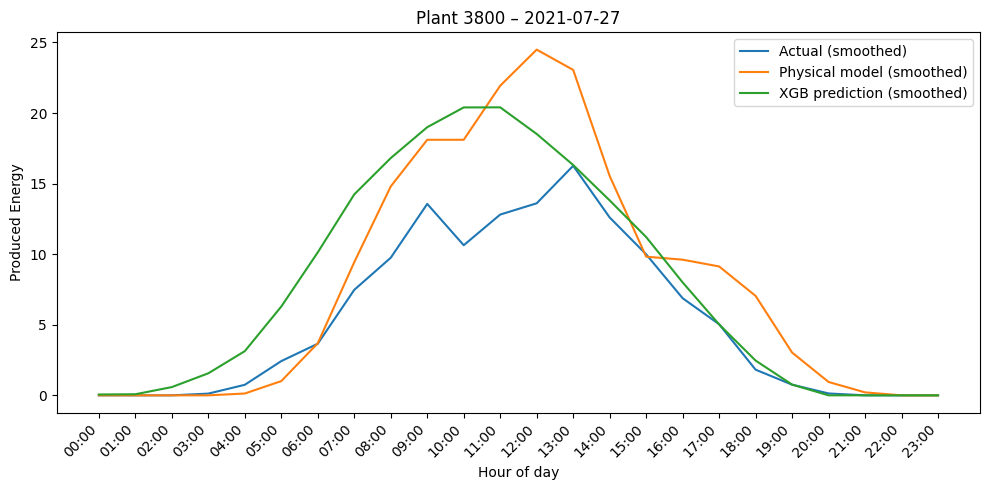

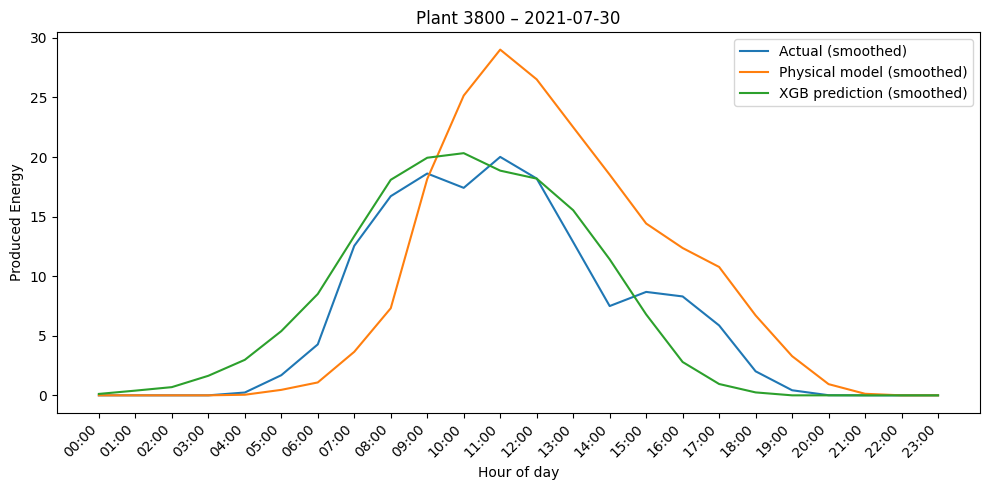

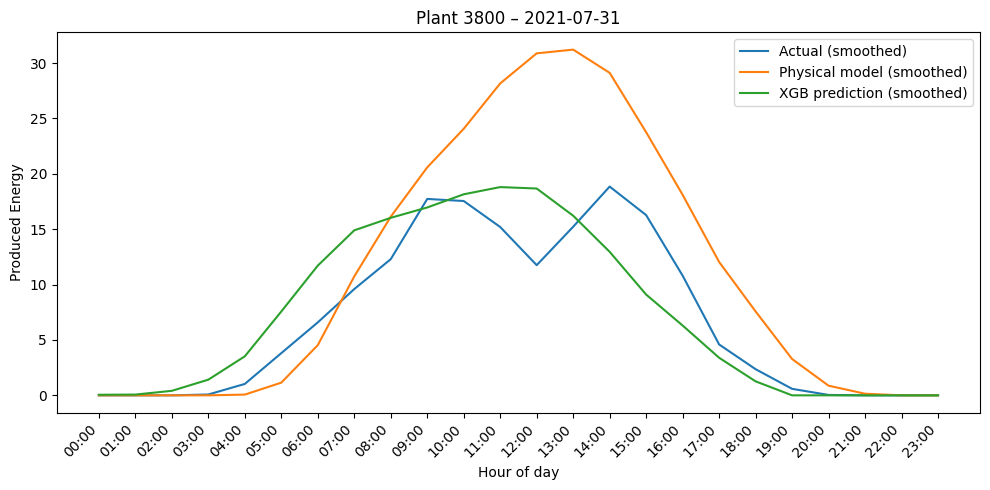

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


CSV_PATH        = "data/UKOpenClimateFix/dataset_feature_engineering.csv"
SELECTED_SERIAL = "3800"
TARGET_DATES = [
    "2021-07-09",
    "2021-07-27",
    "2021-07-30",
    "2021-07-31",
]

df = pd.read_csv(CSV_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df["serial"]   = df["serial"].astype(str)

missing = {"datetime", "serial"} - set(df.columns)
if missing:
    raise ValueError(f"Required column(s) missing: {missing}")

# centred moving average 
def moving_average(series: pd.Series, window: int = 3) -> pd.Series:
    return series.rolling(window=window, center=True, min_periods=1).mean()

for date_str in TARGET_DATES:
    date_obj = datetime.strptime(date_str, "%Y-%m-%d").date()

    # slice 24 hourly rows for this plant & date
    day_df = (
        df[(df["serial"] == SELECTED_SERIAL) & (df["datetime"].dt.date == date_obj)]
        .drop_duplicates(subset="datetime")
        .sort_values("datetime")
        .copy()
    )

    # skip incomplete days
    if len(day_df) != 24 or day_df["datetime"].dt.hour.nunique() != 24:
        print(f"Skipping {date_str}: incomplete data.")
        continue

    # preprocessing 
    day_proc, _ = preprocess_features(
        day_df,
        log_features=[
            "kwp","precipitation","shortwave_radiation","diffuse_radiation",
            "direct_radiation","direct_normal_irradiance","poa",
            "physical_model_prediction"
        ],
        unchanged_features=[
            "is_day","hour_sin","hour_cos",
            "day_of_year","day_of_year_sin","day_of_year_cos",
            "month_sin","month_cos","clearsky_index",
            "relative_physical_model_prediction","relative_output"
        ],
        scale_features=[
            "temperature_2m","relative_humidity_2m","dew_point_2m",
            "pressure_msl","surface_pressure","cloud_cover",
            "wind_speed_10m","wind_direction_10m",
            "solar_zenith","solar_azimuth","solar_elevation","cell_temp"
        ],
        scaler=scaler,
    )

    X_test = day_proc[selected_features]
    preds  = np.maximum(xgb_model.predict(X_test), 0)

    day_proc["predicted_relative_output"] = preds
    day_proc["predicted_output"] = preds * day_df["kwp"].iat[0]
    day_proc["physical_model_prediction"] = np.expm1(day_proc["physical_model_prediction"])

    # smoothing
    day_proc["smooth_actual"]   = moving_average(day_proc["produced energy"])
    day_proc["smooth_physical"] = moving_average(day_proc["physical_model_prediction"])
    day_proc["smooth_xgb"]      = moving_average(day_proc["predicted_output"])

    # plotting
    plt.figure(figsize=(10, 5))
    plt.plot(day_proc["datetime"], day_proc["smooth_actual"],   label="Actual (smoothed)")
    plt.plot(day_proc["datetime"], day_proc["smooth_physical"], label="Physical model (smoothed)")
    plt.plot(day_proc["datetime"], day_proc["smooth_xgb"],      label="XGB prediction (smoothed)")

    plt.xticks(
        ticks=day_proc["datetime"],
        labels=day_proc["datetime"].dt.strftime("%H:%M"),
        rotation=45, ha="right",
    )
    plt.xlabel("Hour of day")
    plt.ylabel("Produced Energy")
    plt.title(f"Plant {SELECTED_SERIAL} – {date_str}")
    plt.legend()
    plt.tight_layout()
    plt.show()
